In [26]:
# ============================================================
# CONFIGURATION — Edit these variables before running
# ============================================================

# Path to the trained model file (.pkl)
MODEL_PATH = "model/CNN-Best-AULA-NUM.pkl"

# Path to the segmented dataset directory for batch testing
DATA_PATH = "Data/combined/test-num"

# Single audio file to test (used for one-off analysis)
# Set to None to skip single-file testing
AUDIO_FILE = None  # e.g. "recordings/segmented/a/sample_001.wav"

# ============================================================
print(f"Model  : {MODEL_PATH}")
print(f"Data   : {DATA_PATH}")
print(f"Audio  : {AUDIO_FILE if AUDIO_FILE else 'Not set'}")


Model  : model/CNN-Best-AULA-NUM.pkl
Data   : Data/combined/test-num
Audio  : Not set


# Grad-CAM Analysis

Standalone Grad-CAM visualization notebook extracted from `CNN.ipynb`.
Visualize which regions of Mel Spectrograms influence the CNN's keystroke predictions.

**Usage:** Run cells top-to-bottom. The standalone loader cell will automatically
find your trained model and prepare everything for visualization.

# 🔍 Grad-CAM: Visual Explanation of CNN Predictions

## What is Grad-CAM?

**Grad-CAM (Gradient-weighted Class Activation Mapping)** is a visualization technique that helps us understand which regions of an input image (in our case, a Mel Spectrogram) the CNN model focuses on when making predictions.

### How Grad-CAM Works

1. **Forward Pass**: The input (Mel Spectrogram) is passed through the CNN to get the predicted class
2. **Backward Pass**: Gradients of the predicted class score are computed with respect to the feature maps of the last convolutional layer
3. **Weight Calculation**: These gradients are globally averaged to get importance weights for each feature map
4. **Activation Map**: The weighted sum of feature maps produces a coarse localization map highlighting important regions
5. **Visualization**: The heatmap is upsampled and overlaid on the original spectrogram

### Why Use the Last Convolutional Layer?

The **last convolutional layer** (`conv4` in our model) is ideal because:
- It has the **highest-level semantic information** (understands "what" features are important)
- It still retains **spatial information** (understands "where" those features are)
- Earlier layers capture low-level features (edges, textures) that are less interpretable
- Fully connected layers lose all spatial information

### Why This Matters for Our Project

For keyboard keystroke detection, Grad-CAM helps us verify that the model is:
- ✅ **Focusing on the keystroke burst** in the Mel Spectrogram (the actual key press sound)
- ✅ **Learning meaningful temporal patterns** (when the key was pressed)
- ✅ **Ignoring background noise** and irrelevant regions
- ❌ **NOT overfitting** to dataset artifacts or noise patterns

If Grad-CAM shows the model focusing on random regions or noise, it indicates the model isn't learning the right features.

## Grad-CAM Implementation

In [27]:
# Install required dependency for Grad-CAM
# opencv-python provides the cv2 module for image processing
try:
    import cv2
    print("✅ opencv-python is already installed")
except ImportError:
    print("📦 Installing opencv-python...")
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "opencv-python"])
    import cv2
    print("✅ opencv-python installed successfully!")

✅ opencv-python is already installed


In [28]:
import cv2
from matplotlib import cm

class GradCAM:
    """
    Grad-CAM (Gradient-weighted Class Activation Mapping) for PyTorch CNNs
    
    This class generates visual explanations showing which regions of the input
    the model focuses on when making predictions.
    """
    
    def __init__(self, model, target_layer):
        """
        Initialize Grad-CAM
        
        Args:
            model: PyTorch CNN model
            target_layer: The layer to visualize (should be last conv layer)
        """
        self.model = model
        self.target_layer = target_layer
        
        # Storage for gradients and activations
        self.gradients = None
        self.activations = None
        
        # Register hooks to capture gradients and activations
        self.register_hooks()
    
    def register_hooks(self):
        """Register forward and backward hooks on the target layer"""
        
        def forward_hook(module, input, output):
            """Capture activations during forward pass"""
            self.activations = output.detach()
        
        def backward_hook(module, grad_input, grad_output):
            """Capture gradients during backward pass"""
            self.gradients = grad_output[0].detach()
        
        # Register the hooks
        self.target_layer.register_forward_hook(forward_hook)
        self.target_layer.register_full_backward_hook(backward_hook)
    
    def generate_cam(self, input_tensor, target_class=None):
        """
        Generate Grad-CAM heatmap for the input
        
        Args:
            input_tensor: Input image tensor (1, C, H, W)
            target_class: Target class index. If None, uses predicted class
            
        Returns:
            cam: Grad-CAM heatmap (H, W) normalized to [0, 1]
            predicted_class: The class used for visualization
            prediction_score: Confidence score for the predicted class
        """
        # Set model to evaluation mode
        self.model.eval()
        
        # Forward pass
        output = self.model(input_tensor)
        
        # Get predicted class if not specified
        if target_class is None:
            target_class = output.argmax(dim=1).item()
        
        # Get prediction score
        prediction_score = torch.softmax(output, dim=1)[0, target_class].item()
        
        # Zero gradients
        self.model.zero_grad()
        
        # Backward pass for the target class
        one_hot = torch.zeros_like(output)
        one_hot[0, target_class] = 1.0
        output.backward(gradient=one_hot, retain_graph=True)
        
        # Calculate weights by global average pooling of gradients
        weights = torch.mean(self.gradients, dim=(2, 3), keepdim=True)
        
        # Weighted combination of activation maps
        cam = torch.sum(weights * self.activations, dim=1, keepdim=True)
        
        # Apply ReLU to focus on positive influence
        cam = torch.relu(cam)
        
        # Normalize to [0, 1]
        cam = cam.squeeze().cpu().numpy()
        cam = cam - cam.min()
        if cam.max() != 0:
            cam = cam / cam.max()
        
        return cam, target_class, prediction_score
    
    def generate_visualization(self, input_tensor, original_image, target_class=None, alpha=0.5):
        """
        Generate overlaid visualization of Grad-CAM on original image
        
        Args:
            input_tensor: Input tensor for the model (1, C, H, W)
            original_image: Original image as numpy array (H, W) or (H, W, C)
            target_class: Target class for CAM. If None, uses predicted class
            alpha: Transparency of heatmap overlay (0=transparent, 1=opaque)
            
        Returns:
            cam: Grad-CAM heatmap
            heatmap_overlay: Heatmap overlaid on original image
            predicted_class: Class index used
            prediction_score: Confidence score
        """
        # Generate CAM
        cam, predicted_class, prediction_score = self.generate_cam(input_tensor, target_class)
        
        # Resize CAM to match input image size
        if original_image.ndim == 2:
            h, w = original_image.shape
        else:
            h, w = original_image.shape[:2]
        
        cam_resized = cv2.resize(cam, (w, h))
        
        # Convert CAM to RGB heatmap using jet colormap
        heatmap = cm.jet(cam_resized)[:, :, :3]  # Remove alpha channel
        heatmap = (heatmap * 255).astype(np.uint8)
        
        # Convert original image to RGB if grayscale
        if original_image.ndim == 2:
            original_rgb = cv2.cvtColor((original_image * 255).astype(np.uint8), 
                                        cv2.COLOR_GRAY2RGB)
        else:
            original_rgb = (original_image * 255).astype(np.uint8)
        
        # Create overlay
        heatmap_overlay = cv2.addWeighted(original_rgb, 1-alpha, heatmap, alpha, 0)
        
        return cam_resized, heatmap_overlay, predicted_class, prediction_score

print("✅ GradCAM class implemented successfully!")

✅ GradCAM class implemented successfully!


## Visualization Helper Functions

In [29]:
def plot_gradcam_single(original_spec, cam_heatmap, overlay, predicted_class, 
                        prediction_score, true_label=None, idx_to_label=None):
    """
    Plot Grad-CAM visualization for a single sample
    
    Args:
        original_spec: Original mel spectrogram (H, W)
        cam_heatmap: Grad-CAM heatmap (H, W)
        overlay: Overlay of heatmap on spectrogram
        predicted_class: Predicted class index
        prediction_score: Confidence score
        true_label: True label (optional)
        idx_to_label: Dictionary mapping class index to label string (optional)
    """
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # Convert label to character if mapping provided
    if idx_to_label:
        pred_char = idx_to_label.get(predicted_class, str(predicted_class))
        true_char = idx_to_label.get(true_label, str(true_label)) if true_label is not None else None
    else:
        pred_char = str(predicted_class)
        true_char = str(true_label) if true_label is not None else None
    
    # Plot original spectrogram
    axes[0].imshow(original_spec, cmap='viridis', aspect='auto')
    axes[0].set_title('Original Mel Spectrogram', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Time')
    axes[0].set_ylabel('Frequency')
    axes[0].axis('off')
    
    # Plot Grad-CAM heatmap
    im = axes[1].imshow(cam_heatmap, cmap='jet', aspect='auto')
    axes[1].set_title('Grad-CAM Heatmap', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Time')
    axes[1].set_ylabel('Frequency')
    axes[1].axis('off')
    plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
    
    # Plot overlay
    axes[2].imshow(overlay)
    title = f'Overlay\nPredicted: {pred_char} ({prediction_score:.2%})'
    if true_char is not None:
        title += f'\nTrue: {true_char}'
    axes[2].set_title(title, fontsize=12, fontweight='bold')
    axes[2].set_xlabel('Time')
    axes[2].set_ylabel('Frequency')
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()


def plot_gradcam_grid(samples, model, gradcam, idx_to_label=None, n_samples=6):
    """
    Plot Grad-CAM visualizations for multiple samples in a grid
    
    Args:
        samples: List of (spectrogram_tensor, label) tuples
        model: Trained CNN model
        gradcam: GradCAM instance
        idx_to_label: Dictionary mapping class index to label string
        n_samples: Number of samples to visualize
    """
    n_samples = min(n_samples, len(samples))
    fig, axes = plt.subplots(n_samples, 3, figsize=(15, 5*n_samples))
    
    if n_samples == 1:
        axes = axes.reshape(1, -1)
    
    for i in range(n_samples):
        spec_tensor, true_label = samples[i]
        
        # Ensure correct shape (1, 1, H, W)
        if spec_tensor.dim() == 2:
            spec_tensor = spec_tensor.unsqueeze(0).unsqueeze(0)
        elif spec_tensor.dim() == 3:
            spec_tensor = spec_tensor.unsqueeze(0)
        
        # Get original spectrogram for visualization
        original_spec = spec_tensor.squeeze().cpu().numpy()
        
        # Generate Grad-CAM
        cam, predicted_class, prediction_score = gradcam.generate_cam(spec_tensor.to(device))
        
        # Resize CAM to match spectrogram
        cam_resized = cv2.resize(cam, (original_spec.shape[1], original_spec.shape[0]))
        
        # Create overlay
        heatmap = cm.jet(cam_resized)[:, :, :3]
        heatmap = (heatmap * 255).astype(np.uint8)
        original_rgb = cv2.cvtColor((original_spec * 255).astype(np.uint8), cv2.COLOR_GRAY2RGB)
        overlay = cv2.addWeighted(original_rgb, 0.5, heatmap, 0.5, 0)
        
        # Convert labels to characters
        if idx_to_label:
            pred_char = idx_to_label.get(predicted_class, str(predicted_class))
            true_char = idx_to_label.get(true_label.item() if torch.is_tensor(true_label) else true_label, '?')
        else:
            pred_char = str(predicted_class)
            true_char = str(true_label.item() if torch.is_tensor(true_label) else true_label)
        
        # Plot original spectrogram
        axes[i, 0].imshow(original_spec, cmap='viridis', aspect='auto')
        if i == 0:
            axes[i, 0].set_title('Original Mel Spectrogram', fontsize=12, fontweight='bold')
        axes[i, 0].set_ylabel(f'Sample {i+1}', fontsize=10)
        axes[i, 0].axis('off')
        
        # Plot Grad-CAM heatmap
        axes[i, 1].imshow(cam_resized, cmap='jet', aspect='auto')
        if i == 0:
            axes[i, 1].set_title('Grad-CAM Heatmap', fontsize=12, fontweight='bold')
        axes[i, 1].axis('off')
        
        # Plot overlay
        axes[i, 2].imshow(overlay)
        if i == 0:
            axes[i, 2].set_title('Overlay + Prediction', fontsize=12, fontweight='bold')
        
        # Add prediction info
        correct = pred_char == true_char
        color = 'green' if correct else 'red'
        axes[i, 2].text(0.5, -0.1, f'Pred: {pred_char} ({prediction_score:.1%}) | True: {true_char}', 
                       transform=axes[i, 2].transAxes, ha='center', fontsize=10,
                       color=color, fontweight='bold')
        axes[i, 2].axis('off')
    
    plt.tight_layout()
    plt.show()

print("✅ Visualization helper functions created!")

✅ Visualization helper functions created!


## Initialize Grad-CAM with Trained Model

In [30]:
# Quick setup: Import required variables if running cells out of order
# This cell ensures all dependencies are available for Grad-CAM analysis

# Check if CNN class is defined
if 'CNN' not in dir():
    print("⚠️  CNN class not found. You need to run cell 29 (define CNN architecture) first!")
    print("   Go to cell 29 (around line 729) and execute it.")
    
# Check if dataset is defined  
if 'dataset' not in dir():
    print("⚠️  Dataset not found. You need to run cell 12 (dataset loading) first!")
    print("   Go to cell 12 (around line 407) and execute it.")

# Check if device is defined
if 'device' not in dir():
    print("⚠️  Device not found. You need to run cell 32 (device detection) first!")
    print("   Go to cell 32 (around line 796) and execute it.")
    
# Check if best_model_path exists (from training)
if 'best_model_path' not in dir():
    print("⚠️  best_model_path not found. Using default path.")
    print("   If you've trained the model, run the training cells to set this variable.")
    best_model_path = "best_model.pth"  # Default fallback
    
# Summary
if all(var in dir() for var in ['CNN', 'dataset', 'device', 'best_model_path']):
    print("✅ All required variables are defined! Ready to initialize Grad-CAM.")
else:
    print("\n❌ Missing required variables. Please run the cells mentioned above first.")


❌ Missing required variables. Please run the cells mentioned above first.


In [31]:
# 🚀 STANDALONE GRAD-CAM LOADER
# Run this cell to load everything needed for Grad-CAM visualization
# No need to run previous cells!

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import os
import cv2
from pathlib import Path

print("="*70)
print(" "*15 + "🚀 LOADING GRAD-CAM DEPENDENCIES")
print("="*70)

# ========== 1. DEFINE CNN CLASS ==========
print("\n1️⃣  Defining CNN architecture...")

class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, padding=1):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=kernel_size, stride=stride, padding=padding),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=kernel_size, stride=1, padding=padding),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)

class CNN(nn.Module):
    def __init__(self, num_classes=36):
        super().__init__()

        self.conv1 = ConvBlock(1, 64)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.dropout1 = nn.Dropout2d(0.25)

        self.conv2 = ConvBlock(64, 128)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.dropout2 = nn.Dropout2d(0.25)

        self.conv3 = ConvBlock(128, 256)
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.dropout3 = nn.Dropout2d(0.3)

        self.conv4 = ConvBlock(256, 512)
        self.pool4 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.dropout4 = nn.Dropout2d(0.3)

        self.global_pool = nn.AdaptiveAvgPool2d(1)

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.conv1(x)
        x = self.pool1(x)
        x = self.dropout1(x)

        x = self.conv2(x)
        x = self.pool2(x)
        x = self.dropout2(x)

        x = self.conv3(x)
        x = self.pool3(x)
        x = self.dropout3(x)

        x = self.conv4(x)
        x = self.pool4(x)
        x = self.dropout4(x)

        x = self.global_pool(x)
        x = self.fc(x)

        return x

print("   ✅ CNN architecture defined")

# ========== 2. SET DEVICE ==========
print("\n2️⃣  Setting up device...")
try:
    if torch.cuda.is_available():
        device = torch.device('cuda')
        print(f"   ✅ Using CUDA GPU: {torch.cuda.get_device_name(0)}")
    else:
        device = torch.device('cpu')
        print("   ✅ Using CPU")
except:
    device = torch.device('cpu')
    print("   ✅ Using CPU (CUDA unavailable)")

# ========== 3. FIND AND LOAD MODEL ==========
print("\n3️⃣  Finding trained model...")

# Use MODEL_PATH from config cell, then fall back to auto-search
best_model_path = None
if 'MODEL_PATH' in dir() and MODEL_PATH and os.path.exists(MODEL_PATH):
    best_model_path = MODEL_PATH
else:
    _fallback_paths = [
        "model/CNN-Best-alphanum-400.pkl",
        "model/CNN-Final-alphanum-400.pkl",
        "model/CNN-Best.pkl",
        "model/CNN-Final.pkl",
    ]
    for path in _fallback_paths:
        if os.path.exists(path):
            best_model_path = path
            break
    if best_model_path is None:
        model_dir = Path("model")
        if model_dir.exists():
            pkl_files = list(model_dir.glob("CNN*.pkl"))
            if pkl_files:
                best_model_path = str(pkl_files[0])

if best_model_path is None:
    print("   ❌ No model file found!")
    print("   Set MODEL_PATH in the top configuration cell.")
    raise FileNotFoundError("No trained model found")

print(f"   ✅ Found model: {best_model_path}")

# Load model
print("\n4️⃣  Loading model weights...")
try:
    state_dict = torch.load(best_model_path, map_location=device)
    
    if 'fc.7.weight' in state_dict:
        num_classes = state_dict['fc.7.weight'].shape[0]
    else:
        num_classes = 36  # Default
    
    print(f"   Detected {num_classes} output classes")
    
    model_gradcam = CNN(num_classes=num_classes).to(device)
    model_gradcam.load_state_dict(state_dict)
    model_gradcam.eval()
    
    print(f"   ✅ Model loaded successfully!")
    print(f"   Parameters: {sum(p.numel() for p in model_gradcam.parameters()):,}")
except Exception as e:
    print(f"   ❌ Error loading model: {e}")
    raise

# ========== 5. CREATE LABEL MAPPING ==========
print("\n5️⃣  Creating label mapping...")  

if num_classes == 36:
    chars = [str(i) for i in range(10)] + [chr(ord('a') + i) for i in range(26)]
    idx_to_label = {i: chars[i] for i in range(36)}
    print(f"   ✅ Alphanumeric labels (0-9, a-z)")
elif num_classes == 26:
    chars = [chr(ord('a') + i) for i in range(26)]
    idx_to_label = {i: chars[i] for i in range(26)}
    print(f"   ✅ Alphabetic labels (a-z)")
elif num_classes == 10:
    chars = [str(i) for i in range(10)]
    idx_to_label = {i: chars[i] for i in range(10)}
    print(f"   ✅ Numeric labels (0-9)")
else:
    idx_to_label = {i: f"class_{i}" for i in range(num_classes)}
    print(f"   ✅ Generic labels for {num_classes} classes")

print(f"   Sample mappings: {dict(list(idx_to_label.items())[:10])}")

# ========== 6. LOAD TEST DATASET ==========
print("\n6️⃣  Loading test dataset...")  

try:
    if 'test_set' in dir() and test_set is not None:
        print(f"   ✅ Using existing test_set with {len(test_set)} samples")
    else:
        import torchaudio
        from torch.utils.data import Dataset

        # Use DATA_PATH from config cell, then fall back to defaults
        _data_search = (
            [DATA_PATH] if 'DATA_PATH' in dir() and DATA_PATH else []
        ) + [
            "Data/segmented/alphanum-400",
            "Data/segmented/alphanum-soft-100",
            "Data/segmented/num-large",
        ]

        dataset = None
        for data_path in _data_search:
            if os.path.exists(data_path):
                print(f"   Loading from: {data_path}")
                if 'AudioDataset' in dir():
                    dataset = AudioDataset(data_path, None)
                    test_set = dataset
                    print(f"   ✅ Loaded {len(dataset)} samples")
                    break

        if dataset is None:
            print("   ⚠️  No dataset loaded (optional for single-image visualization)")
            test_set = None
except Exception as e:
    print(f"   ⚠️  Could not load dataset: {e}")
    test_set = None
    dataset = None

print("\n" + "="*70)
print(" "*20 + "✅ ALL READY FOR GRAD-CAM!")
print("="*70)
print(f"\n📋 Summary:")
print(f"   • Model: {best_model_path}")
print(f"   • Classes: {num_classes}")
print(f"   • Device: {device}")
print(f"   • Test samples: {len(test_set) if test_set else 'N/A (use manual spectrograms)'}")
print(f"\n🎯 You can now run the Grad-CAM visualization cells below!")
print("="*70)


               🚀 LOADING GRAD-CAM DEPENDENCIES

1️⃣  Defining CNN architecture...
   ✅ CNN architecture defined

2️⃣  Setting up device...
   ✅ Using CUDA GPU: NVIDIA GeForce RTX 3060 Laptop GPU

3️⃣  Finding trained model...
   ✅ Found model: model/CNN-Best-AULA-NUM.pkl

4️⃣  Loading model weights...
   Detected 10 output classes
   ✅ Model loaded successfully!
   Parameters: 4,853,578

5️⃣  Creating label mapping...
   ✅ Numeric labels (0-9)
   Sample mappings: {0: '0', 1: '1', 2: '2', 3: '3', 4: '4', 5: '5', 6: '6', 7: '7', 8: '8', 9: '9'}

6️⃣  Loading test dataset...
   ✅ Using existing test_set with 410 samples

                    ✅ ALL READY FOR GRAD-CAM!

📋 Summary:
   • Model: model/CNN-Best-AULA-NUM.pkl
   • Classes: 10
   • Device: cuda
   • Test samples: 410

🎯 You can now run the Grad-CAM visualization cells below!


In [32]:
# Initialize Grad-CAM targeting the last convolutional layer (conv4)
# conv4 is the last convolutional block before pooling and fully connected layers
gradcam = GradCAM(model_gradcam, target_layer=model_gradcam.conv4)

print("\n✅ Grad-CAM initialized successfully!")
print(f"   Target layer: conv4 (last convolutional block)")
print(f"   Device: {device}")
print(f"   Model parameters: {sum(p.numel() for p in model_gradcam.parameters()):,}")
print(f"   Ready to visualize model predictions!")


✅ Grad-CAM initialized successfully!
   Target layer: conv4 (last convolutional block)
   Device: cuda
   Model parameters: 4,853,578
   Ready to visualize model predictions!


In [33]:
# Create label mapping (index -> character)
# This assumes your dataset has alphanumeric labels (0-9, a-z)
idx_to_label = {}

# Create reverse mapping from the dataset's label_map
if hasattr(dataset, 'label_map'):
    for label_str, idx in dataset.label_map.items():
        idx_to_label[idx] = label_str
    print(f"✅ Label mapping created: {len(idx_to_label)} classes")
    print(f"   Sample mappings: {dict(list(idx_to_label.items())[:10])}")
else:
    # Fallback: create default alphanumeric mapping
    chars = [str(i) for i in range(10)] + [chr(ord('a') + i) for i in range(26)]
    idx_to_label = {i: chars[i] for i in range(len(chars))}
    print(f"✅ Default label mapping created: {len(idx_to_label)} classes")

✅ Label mapping created: 10 classes
   Sample mappings: {0: '0', 1: '1', 2: '2', 3: '3', 4: '4', 5: '5', 6: '6', 7: '7', 8: '8', 9: '9'}


In [34]:
# AudioDataset class definition (required for loading data in this standalone notebook)
import torchaudio
import soundfile as sf

class AudioDataset(torch.utils.data.Dataset):
    def __init__(self, data_dir, transform=None):
        self.data_dir = data_dir
        self.transform = transform
        self.n_samples = 0
        self.dataset = []
        self.labels = set()
        self.label_map = {}  # maps raw label string -> contiguous index
        self.load_audio_files(self.data_dir)

    def load_audio_files(self, path: str):
        # First pass: collect all valid label strings
        raw_labels = set()
        for dirname, _, filenames in os.walk(path):
            label = os.path.basename(dirname)
            if filenames and (('0' <= label <= '9') or ('a' <= label <= 'z')):
                raw_labels.add(label)

        # Build contiguous label map (sorted for consistency)
        for idx, label in enumerate(sorted(raw_labels)):
            self.label_map[label] = idx

        # Second pass: load files
        for dirname, _, filenames in os.walk(path):
            for filename in filenames:
                file_path = os.path.join(dirname, filename)
                label = os.path.basename(dirname)

                if label not in self.label_map:
                    continue

                label_index = self.label_map[label]
                label_tensor = torch.tensor(label_index)
                self.labels.add(label_tensor.item())

                try:
                    waveform, sample_rate = torchaudio.load(file_path)
                except (ImportError, RuntimeError):
                    audio_data, sample_rate = sf.read(file_path)
                    waveform = torch.from_numpy(audio_data).float()
                    if waveform.ndim == 1:
                        waveform = waveform.unsqueeze(0)
                    elif waveform.ndim == 2:
                        waveform = waveform.T

                self.n_samples += 1
                self.dataset.append((waveform, label_tensor))

    def __len__(self):
        return self.n_samples

    def __getitem__(self, idx):
        waveform, label = self.dataset[idx]
        if self.transform is not None:
            waveform = self.transform(waveform)
        return waveform, label

    def num_classes(self):
        return len(self.labels)

print("✅ AudioDataset class defined!")


✅ AudioDataset class defined!


In [35]:
# Load test dataset for visualization with PROPER TRANSFORMS
print("📂 Loading test dataset for Grad-CAM visualization...")

# Define the same transforms used during training
import torchaudio
import torch.nn.functional as F
from torchvision.transforms import Compose, ToTensor

sample_rate = 44100
to_mel_spectrogram = torchaudio.transforms.MelSpectrogram(
    sample_rate=sample_rate, 
    n_mels=64, 
    hop_length=300, 
    n_fft=2048, 
    win_length=1024
)
mel_spectrogram_to_numpy = lambda spectrogram: spectrogram.clamp(min=1e-9).log2()[0,:,:].numpy()

# Add resize function to ensure 64x64 shape
def resize_to_64x64(spec_tensor):
    """Resize spectrogram tensor to 64x64"""
    if spec_tensor.dim() == 2:
        spec_tensor = spec_tensor.unsqueeze(0).unsqueeze(0)
    elif spec_tensor.dim() == 3:
        spec_tensor = spec_tensor.unsqueeze(0)
    resized = F.interpolate(spec_tensor, size=(64, 64), mode='bilinear', align_corners=False)
    return resized.squeeze(0)

transforms = Compose([to_mel_spectrogram, mel_spectrogram_to_numpy, ToTensor(), resize_to_64x64])

# Use DATA_PATH from the top configuration cell
data_path = DATA_PATH if 'DATA_PATH' in dir() and DATA_PATH else "Data/segmented/alphanum-400"

if os.path.exists(data_path):
    dataset = AudioDataset(data_path, transform=transforms)
    test_set = dataset
    print(f"✅ Loaded {len(test_set)} test samples")
    print(f"   Classes: {dataset.num_classes()}")
    print(f"   Data path: {data_path}")
    print(f"   Spectrogram shape will be: (1, 64, 64) after transforms")
else:
    print(f"❌ Test data path not found: {data_path}")
    print(f"   Update DATA_PATH in the top configuration cell.")
    test_set = None


📂 Loading test dataset for Grad-CAM visualization...
✅ Loaded 410 test samples
   Classes: 10
   Data path: Data/combined/test-num
   Spectrogram shape will be: (1, 64, 64) after transforms


## Visualize Grad-CAM on Test Samples

Now let's visualize Grad-CAM for individual test samples to see which regions of the Mel Spectrogram the model focuses on.

Analyzing sample 0...
  True label: 7
  Spectrogram shape: torch.Size([1, 64, 64])

📊 Prediction Results:
  Predicted: 8 (confidence: 100.00%)
  True label: 7
  Correct: ❌ No


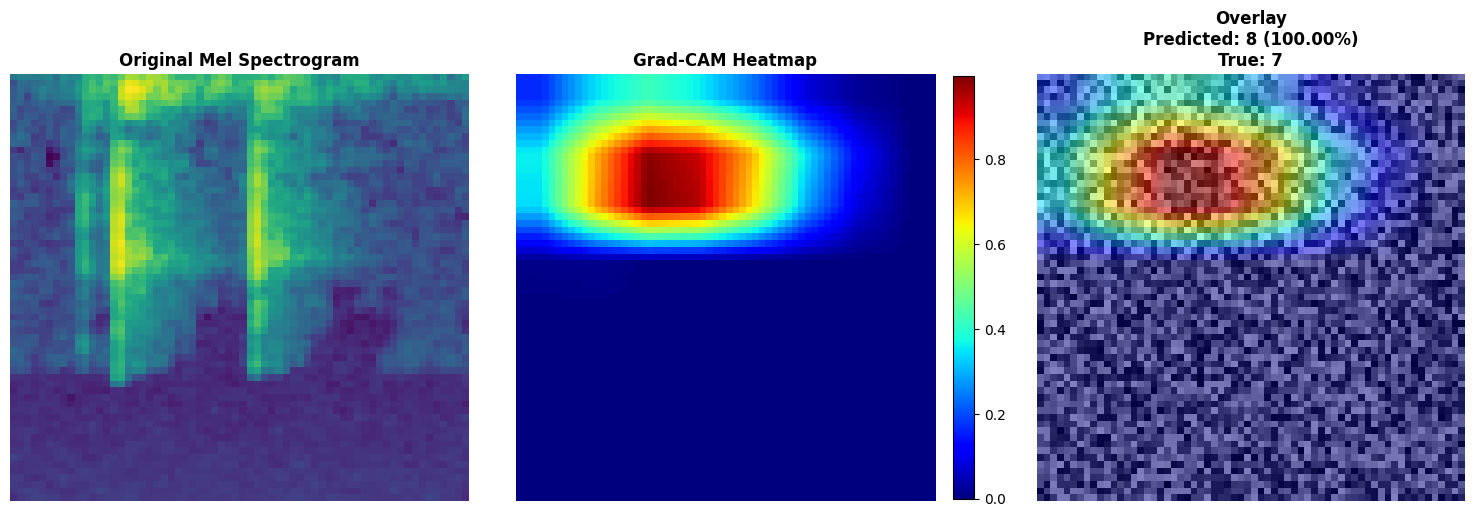

In [36]:
# Select a test sample (you can change the index to visualize different samples)
sample_idx = 0
spec_tensor, true_label = test_set[sample_idx]

print(f"Analyzing sample {sample_idx}...")
print(f"  True label: {idx_to_label.get(true_label.item(), true_label.item())}")
print(f"  Spectrogram shape: {spec_tensor.shape}")

# Ensure correct shape (1, 1, H, W) for model input
if spec_tensor.dim() == 2:
    input_tensor = spec_tensor.unsqueeze(0).unsqueeze(0).to(device)
elif spec_tensor.dim() == 3:
    input_tensor = spec_tensor.unsqueeze(0).to(device)
else:
    input_tensor = spec_tensor.to(device)

# Get original spectrogram for visualization
original_spec = spec_tensor.squeeze().cpu().numpy()

# Generate Grad-CAM visualization
cam, heatmap_overlay, predicted_class, prediction_score = gradcam.generate_visualization(
    input_tensor, 
    original_spec,
    alpha=0.5
)

# Display results
print(f"\n📊 Prediction Results:")
print(f"  Predicted: {idx_to_label.get(predicted_class, predicted_class)} (confidence: {prediction_score:.2%})")
print(f"  True label: {idx_to_label.get(true_label.item(), true_label.item())}")
print(f"  Correct: {'✅ Yes' if predicted_class == true_label.item() else '❌ No'}")

# Plot visualization
plot_gradcam_single(
    original_spec, 
    cam, 
    heatmap_overlay, 
    predicted_class, 
    prediction_score,
    true_label=true_label.item(),
    idx_to_label=idx_to_label
)

## Visualize Multiple Samples in a Grid

Let's visualize Grad-CAM for multiple test samples at once to compare how the model focuses on different keystroke patterns.

Visualizing Grad-CAM for 6 test samples...


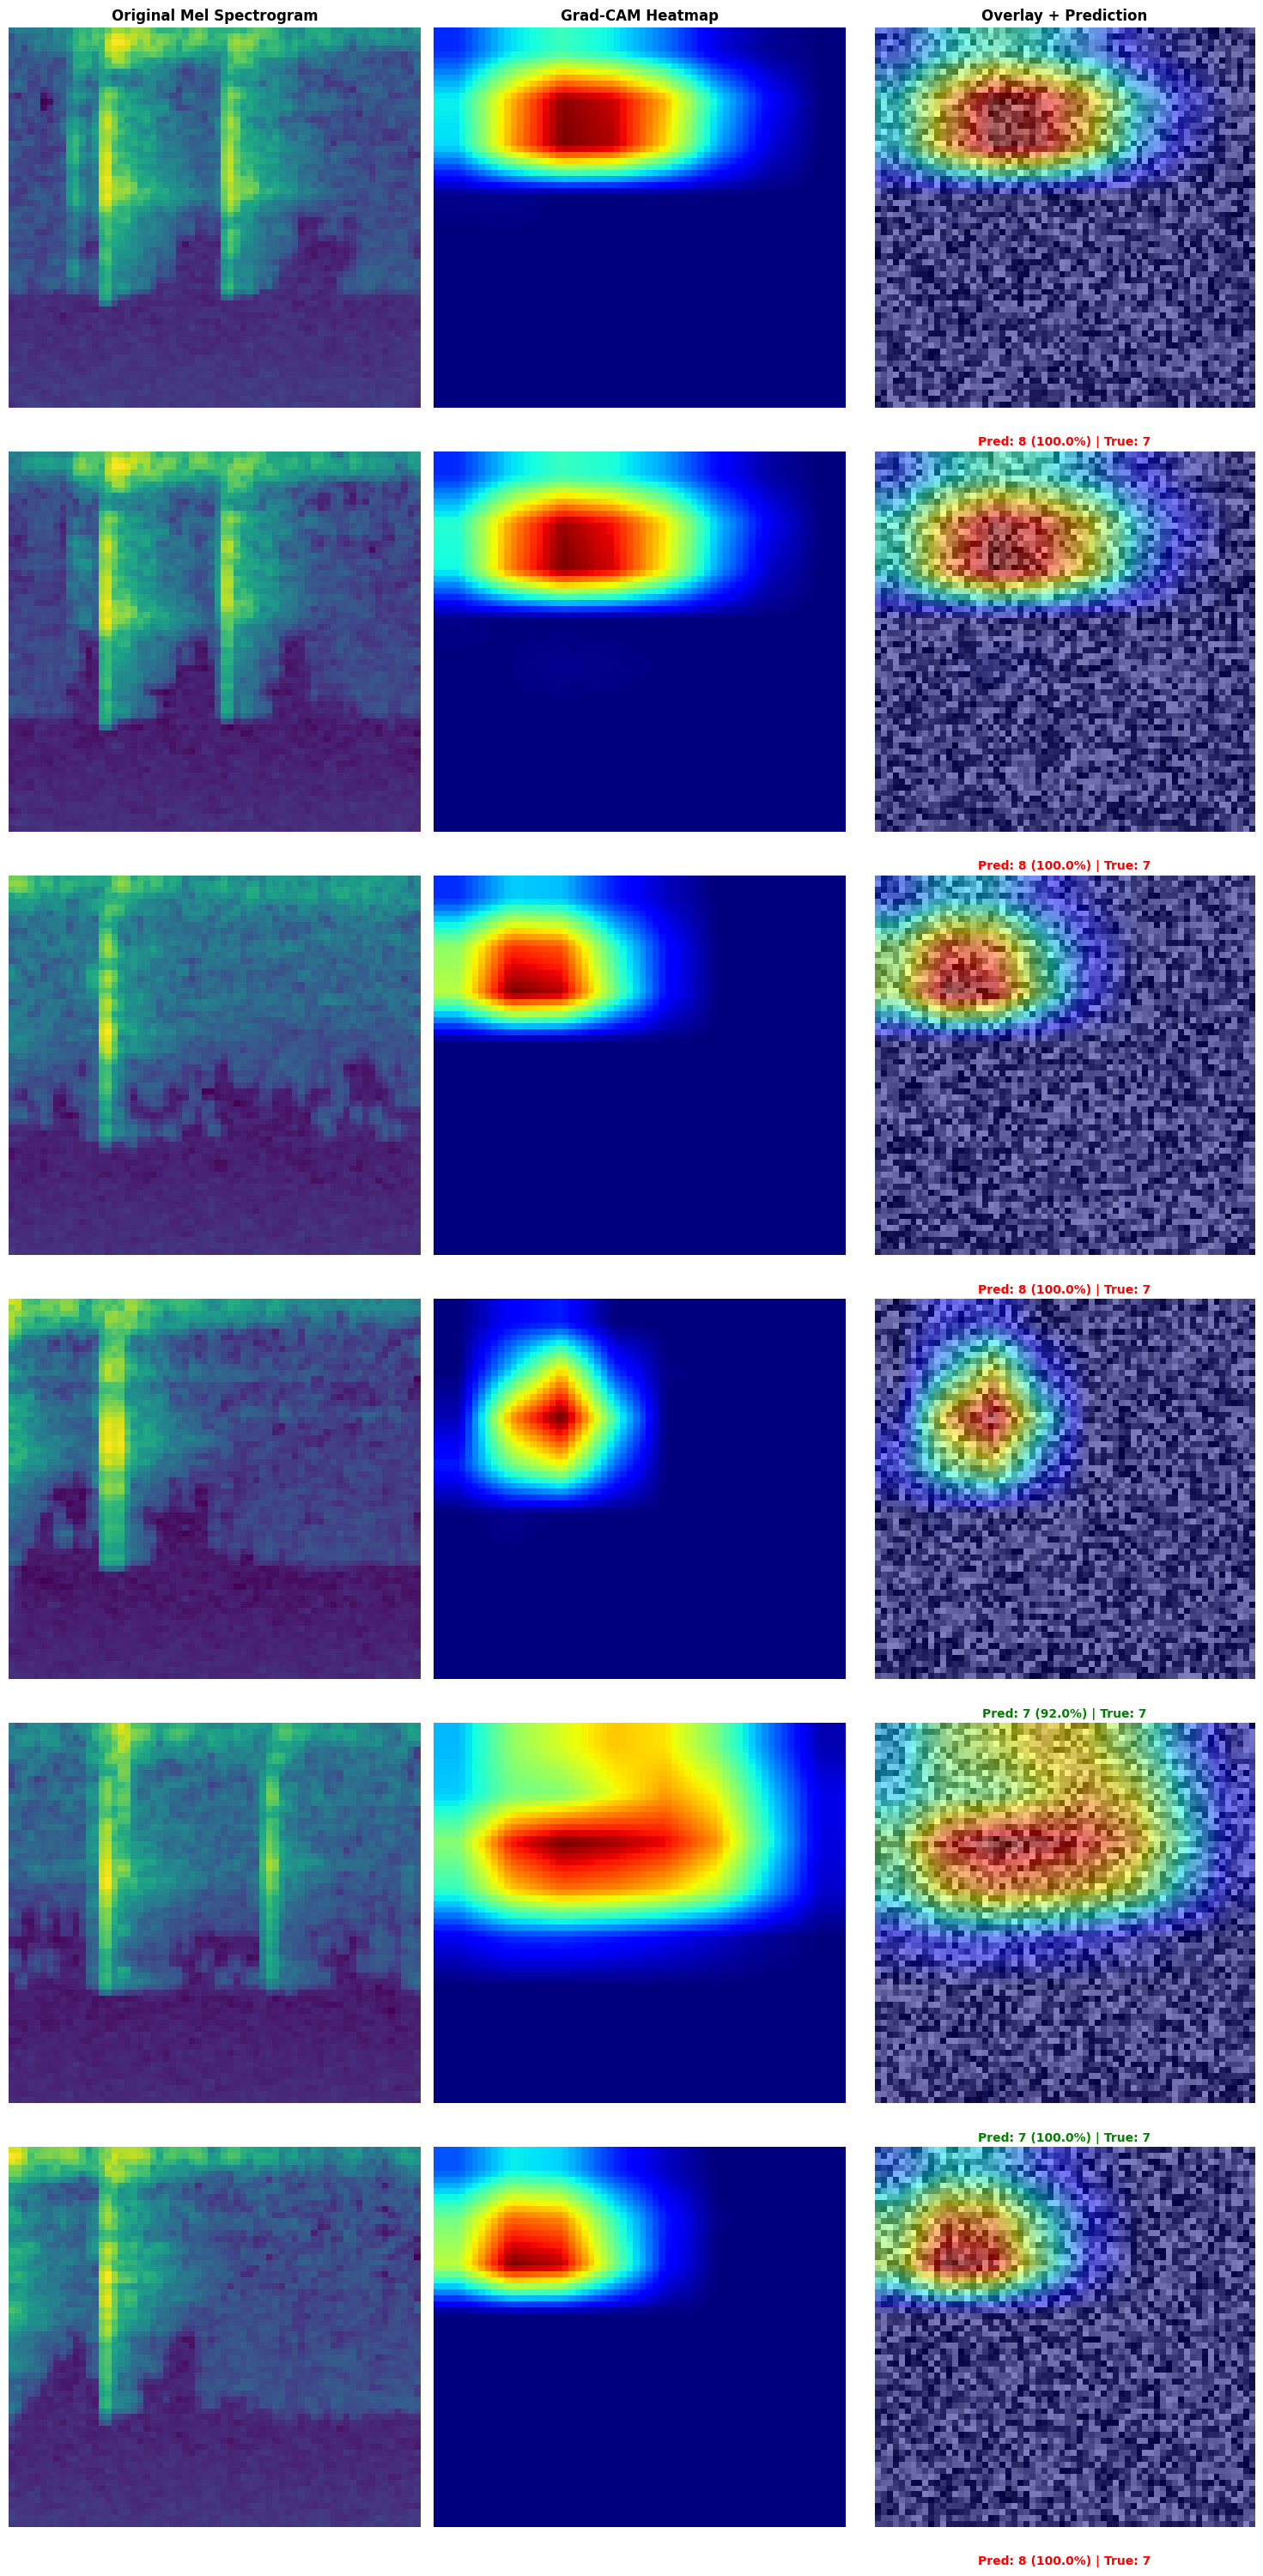

In [37]:
# Visualize multiple samples
n_samples = 6  # Change this to visualize more or fewer samples

# Collect samples from test set
test_samples = [test_set[i] for i in range(min(n_samples, len(test_set)))]

print(f"Visualizing Grad-CAM for {len(test_samples)} test samples...")

# Plot grid visualization
plot_gradcam_grid(
    test_samples, 
    model_gradcam, 
    gradcam, 
    idx_to_label=idx_to_label,
    n_samples=n_samples
)

## Compare Correct vs Incorrect Predictions

Let's specifically look at samples where the model made correct predictions vs incorrect predictions to understand what the model is learning.

🔍 Analyzing test set to find correct and incorrect predictions...
✅ Found 3 correct predictions and 4 incorrect predictions

📊 Grad-CAM for CORRECT Predictions:


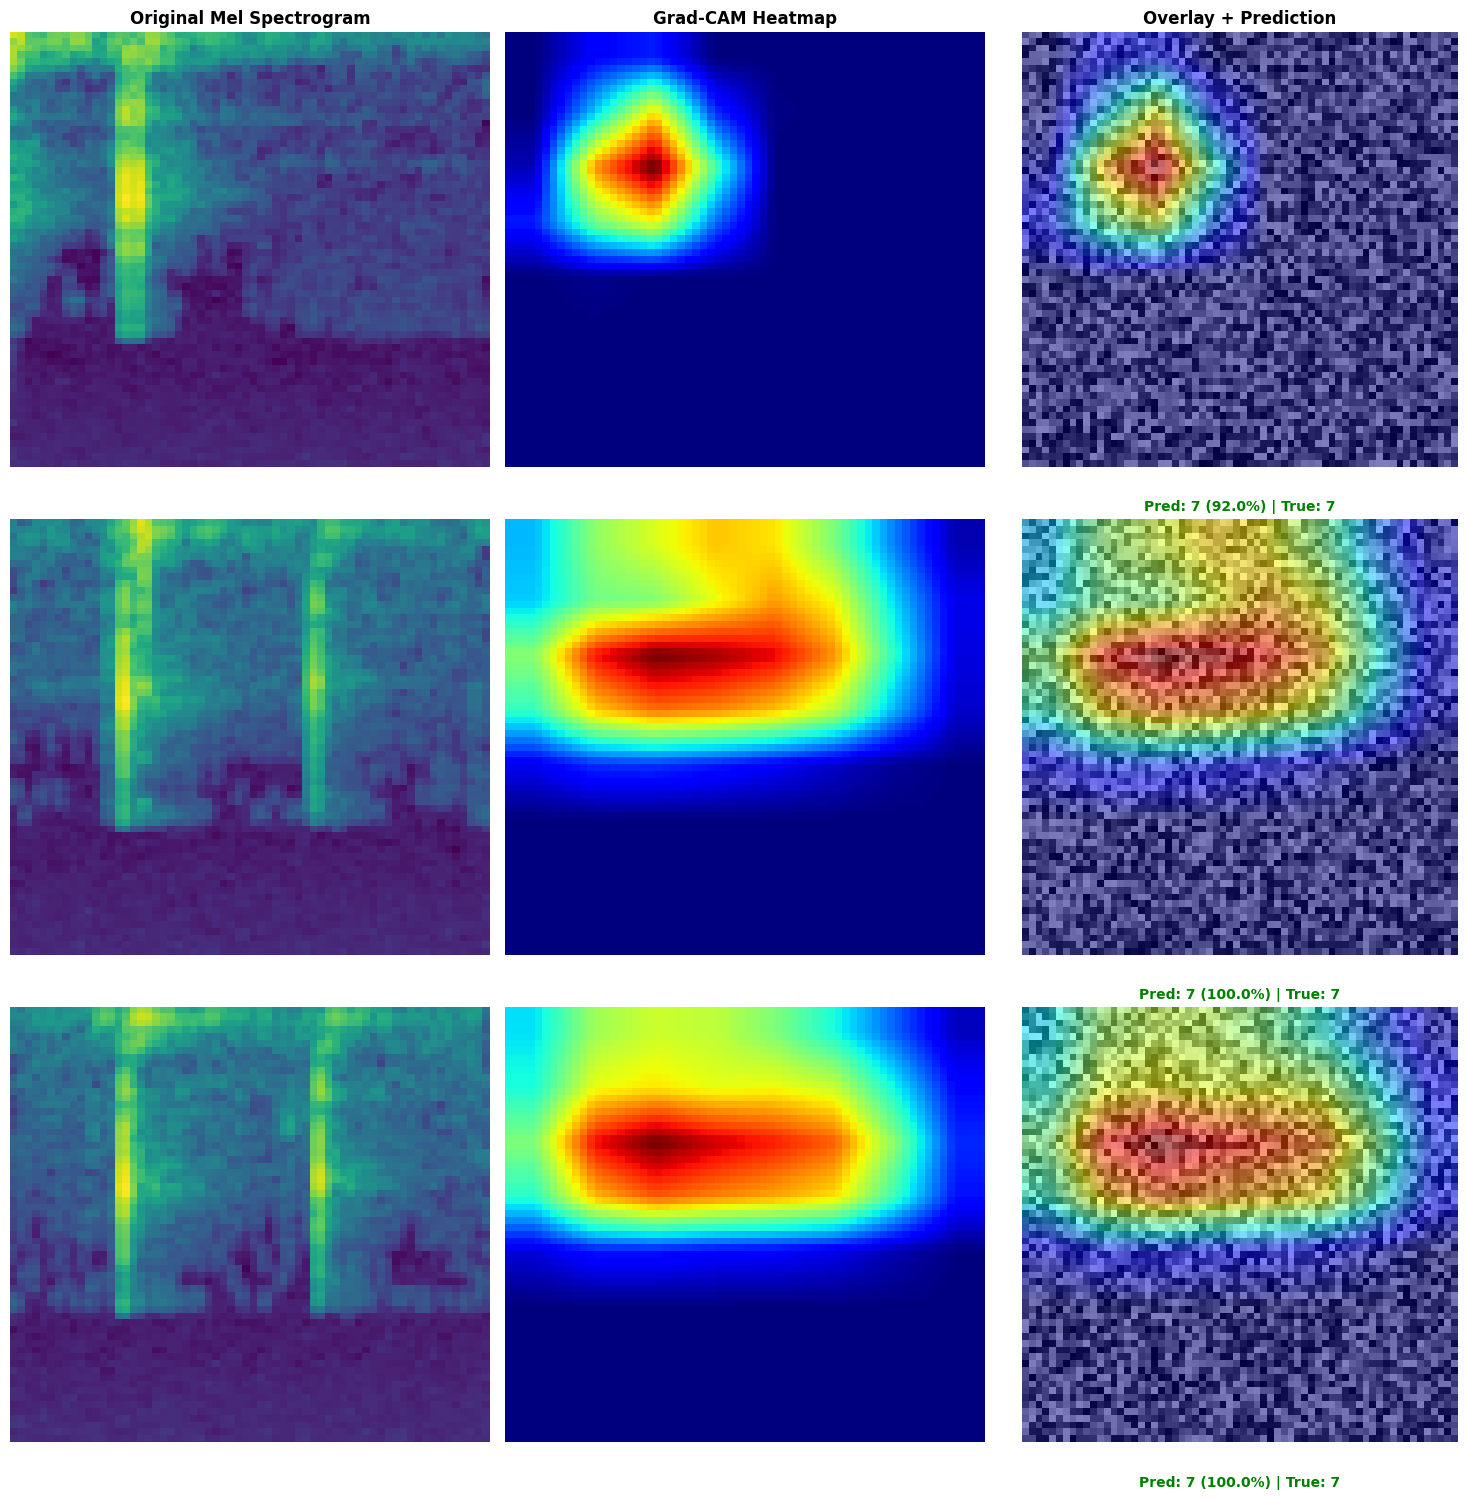


📊 Grad-CAM for INCORRECT Predictions:


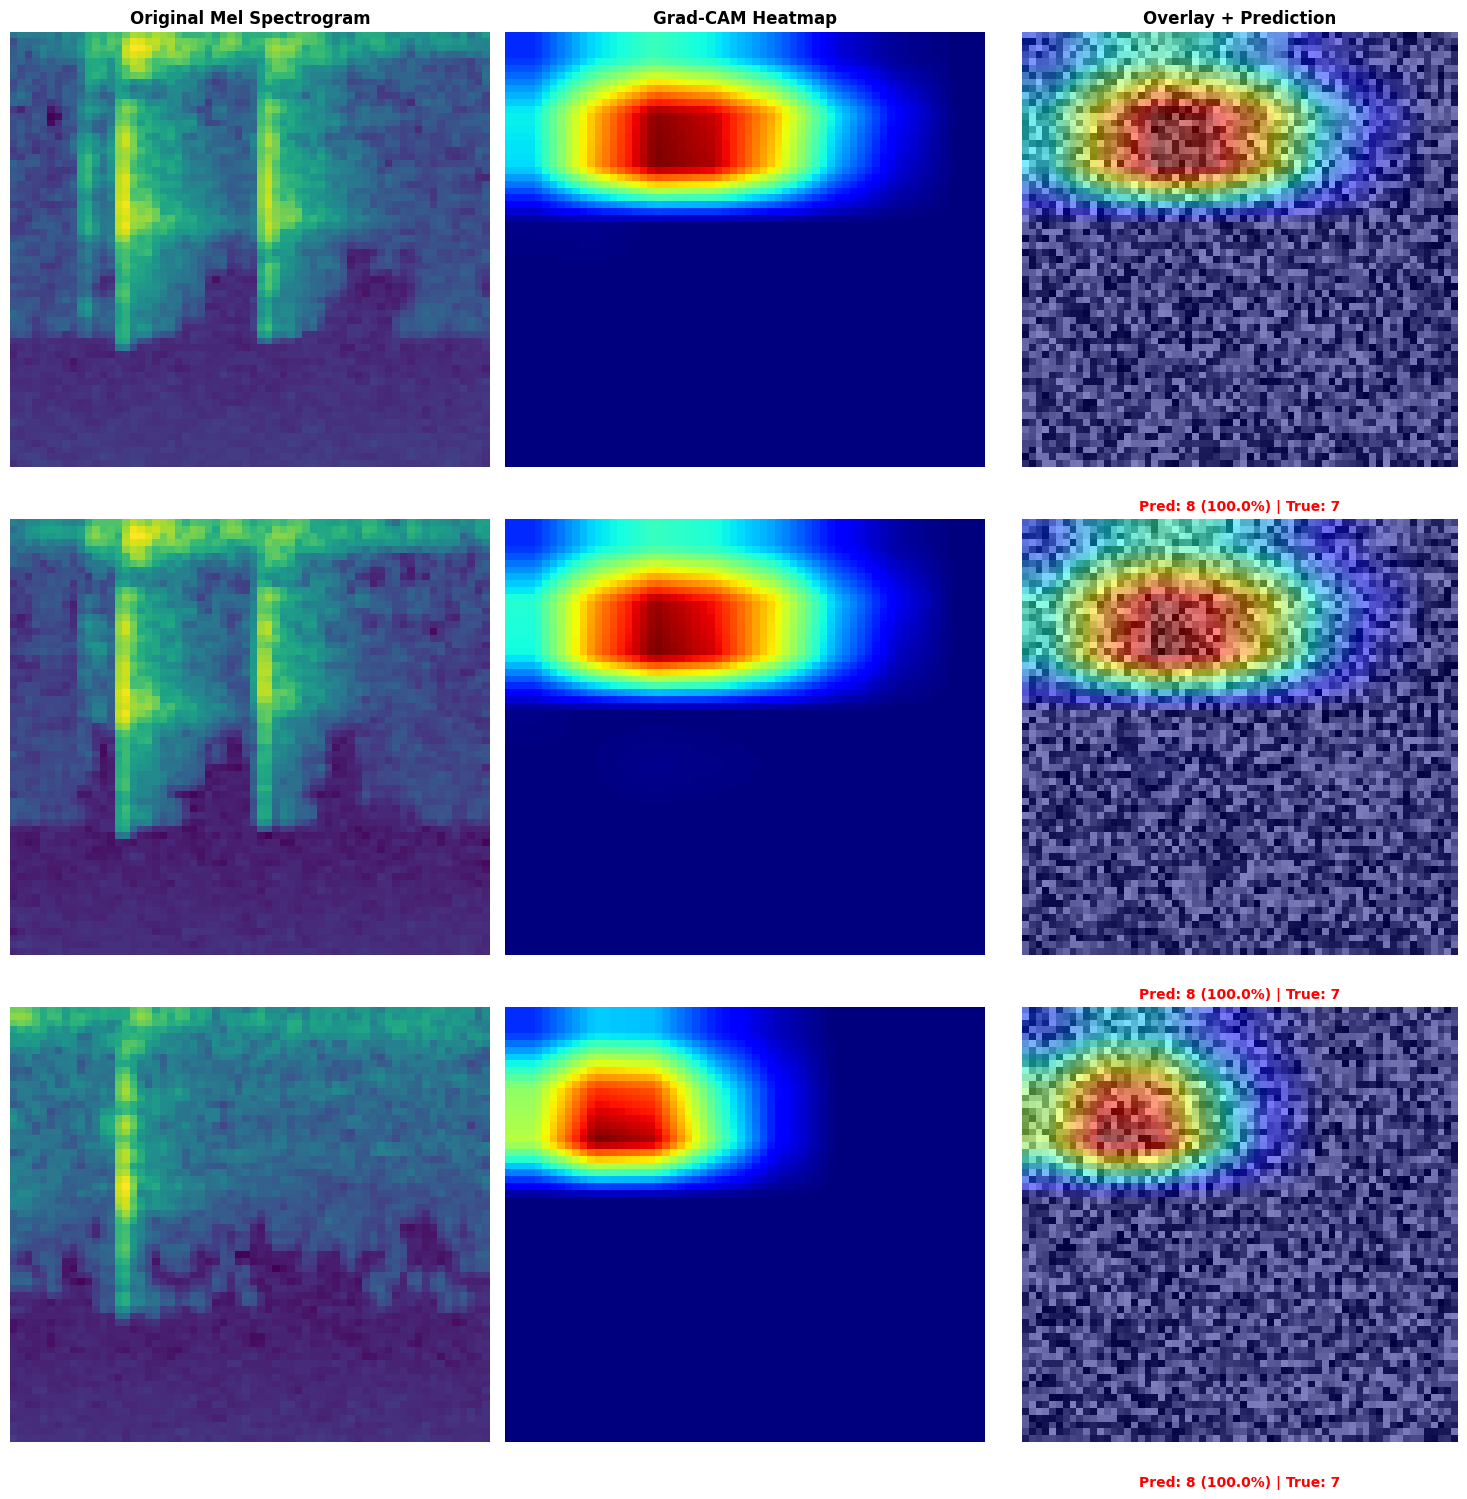

In [38]:
# Find correct and incorrect predictions
correct_samples = []
incorrect_samples = []

print("🔍 Analyzing test set to find correct and incorrect predictions...")

model_gradcam.eval()
with torch.no_grad():
    for i in range(min(100, len(test_set))):  # Check first 100 samples
        spec_tensor, true_label = test_set[i]
        
        # Prepare input
        if spec_tensor.dim() == 2:
            input_tensor = spec_tensor.unsqueeze(0).unsqueeze(0).to(device)
        elif spec_tensor.dim() == 3:
            input_tensor = spec_tensor.unsqueeze(0).to(device)
        else:
            input_tensor = spec_tensor.to(device)
        
        # Get prediction
        output = model_gradcam(input_tensor)
        predicted_class = output.argmax(dim=1).item()
        
        # Store sample
        if predicted_class == true_label.item():
            correct_samples.append((spec_tensor, true_label))
        else:
            incorrect_samples.append((spec_tensor, true_label))
        
        # Stop when we have enough samples
        if len(correct_samples) >= 3 and len(incorrect_samples) >= 3:
            break

print(f"✅ Found {len(correct_samples)} correct predictions and {len(incorrect_samples)} incorrect predictions")

# Visualize correct predictions
if len(correct_samples) > 0:
    print("\n📊 Grad-CAM for CORRECT Predictions:")
    plot_gradcam_grid(correct_samples[:3], model_gradcam, gradcam, idx_to_label=idx_to_label, n_samples=min(3, len(correct_samples)))

# Visualize incorrect predictions
if len(incorrect_samples) > 0:
    print("\n📊 Grad-CAM for INCORRECT Predictions:")
    plot_gradcam_grid(incorrect_samples[:3], model_gradcam, gradcam, idx_to_label=idx_to_label, n_samples=min(3, len(incorrect_samples)))

## Analyzing Specific Keys (Optional)

You can also analyze how the model focuses on specific keys by filtering samples by label.

🔍 Collecting samples for keys: ['a', 'e', '5', '9']...
⚠️ No samples found for key 'a' in test set
⚠️ No samples found for key 'e' in test set

📊 Grad-CAM Analysis for Key: '5'


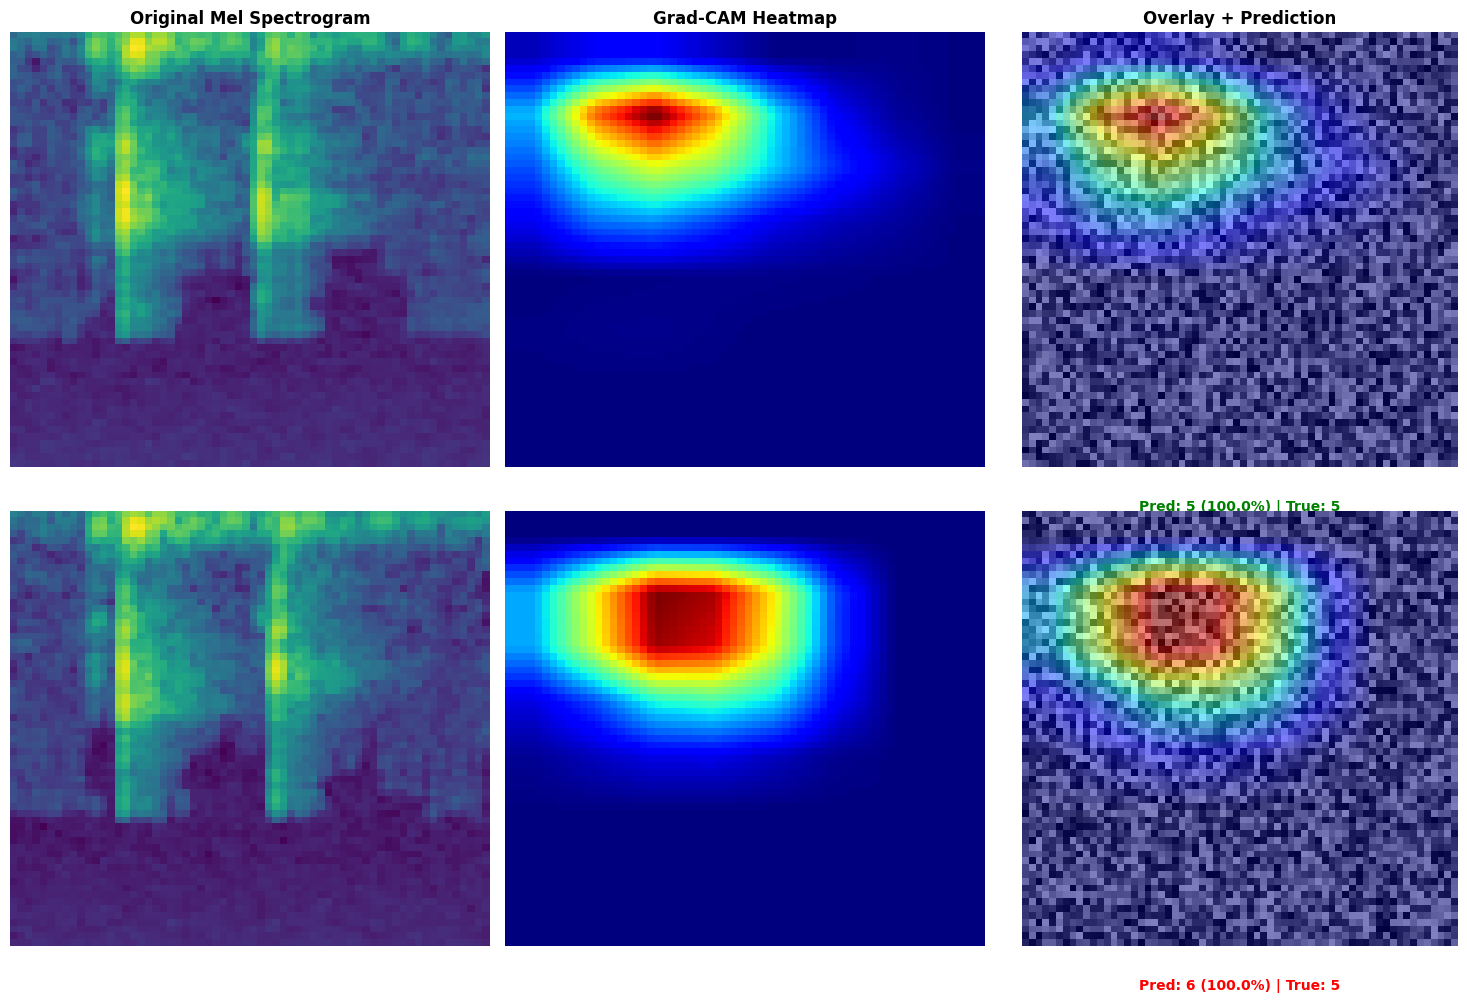


📊 Grad-CAM Analysis for Key: '9'


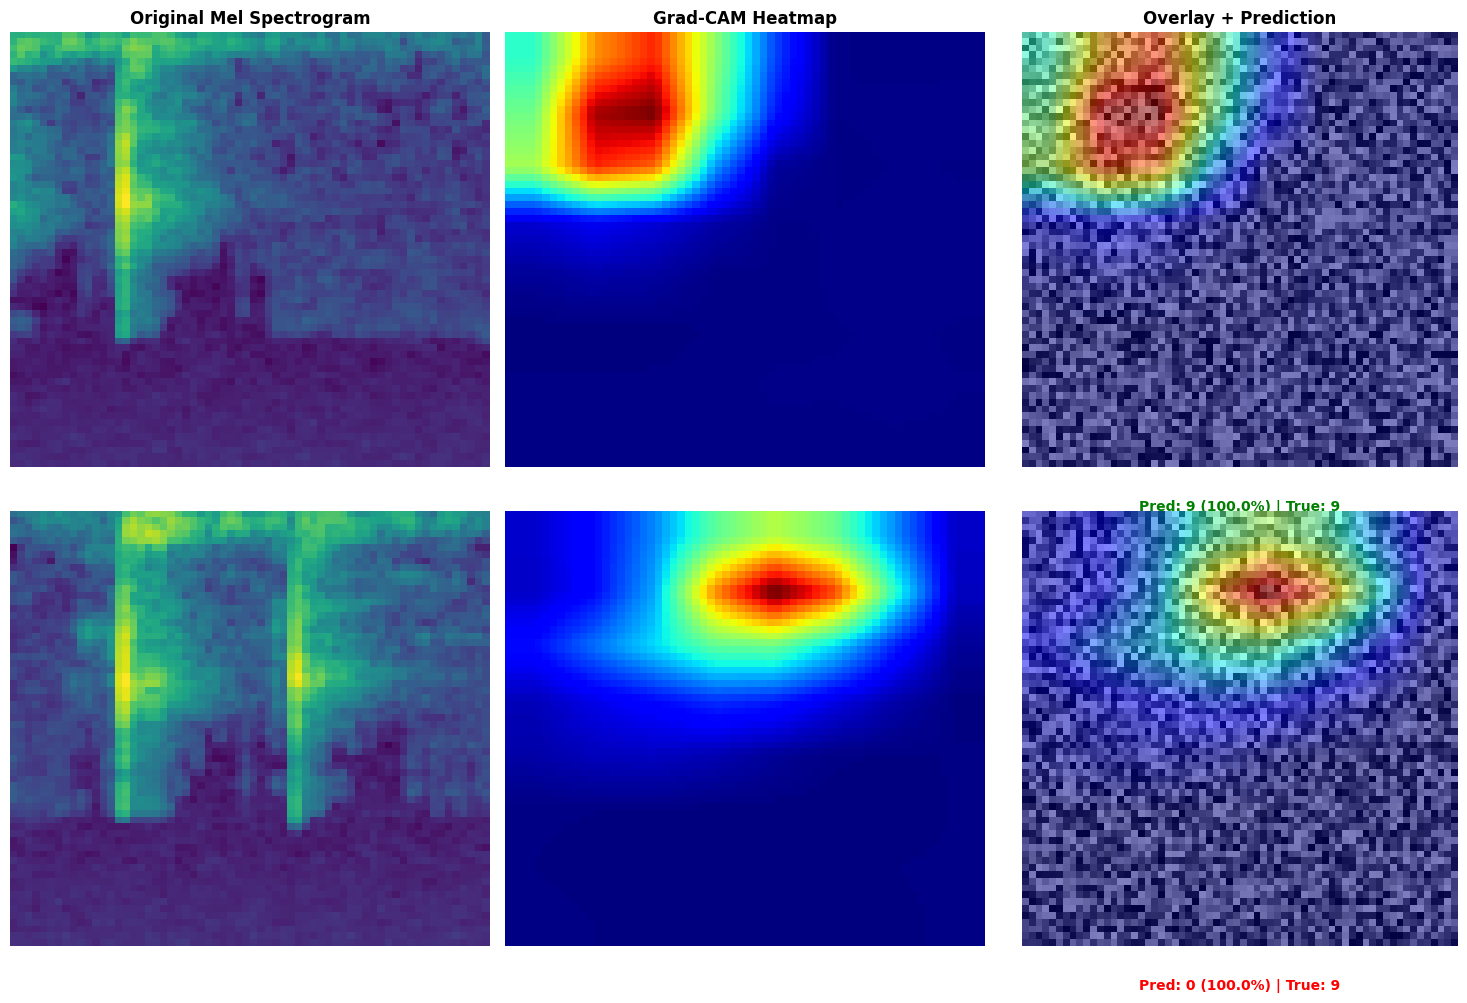

In [39]:
# Analyze specific keys (e.g., compare 'a', 'e', '5', '9')
target_keys = ['a', 'e', '5', '9']  # Change these to any keys you want to analyze

# Create reverse label mapping
label_to_idx = {v: k for k, v in idx_to_label.items()}

# Collect samples for target keys
key_samples = {key: [] for key in target_keys}

print(f"🔍 Collecting samples for keys: {target_keys}...")

for i in range(len(test_set)):
    spec_tensor, true_label = test_set[i]
    true_char = idx_to_label.get(true_label.item(), None)
    
    if true_char in target_keys and len(key_samples[true_char]) < 2:
        key_samples[true_char].append((spec_tensor, true_label))
    
    # Stop when we have enough samples for all keys
    if all(len(samples) >= 2 for samples in key_samples.values()):
        break

# Visualize Grad-CAM for each key
for key in target_keys:
    if len(key_samples[key]) > 0:
        print(f"\n📊 Grad-CAM Analysis for Key: '{key.upper()}'")
        plot_gradcam_grid(
            key_samples[key], 
            model_gradcam, 
            gradcam, 
            idx_to_label=idx_to_label,
            n_samples=len(key_samples[key])
        )
    else:
        print(f"⚠️ No samples found for key '{key}' in test set")

## 📖 Interpreting Grad-CAM Results

### What to Look For

**Good Signs (Model Learning Correctly):**
- 🟢 **Focused attention on keystroke burst**: Heatmap highlights the bright region in the spectrogram where the key press sound occurs
- 🟢 **Temporal localization**: Attention is concentrated in a specific time window (horizontal region)
- 🟢 **Frequency patterns**: Attention may focus on specific frequency bands unique to different keys
- 🟢 **Consistent patterns**: Similar keys show similar attention patterns

**Warning Signs (Potential Issues):**
- 🔴 **Random/scattered attention**: Heatmap shows no clear pattern or focuses on noise regions
- 🔴 **Edge artifacts**: Model focuses on edges of the spectrogram (dataset artifact)
- 🔴 **Background focus**: Attention on low-energy regions (background noise)
- 🔴 **Inconsistent patterns**: Same key shows very different attention patterns

### Understanding the Visualizations

1. **Original Mel Spectrogram**: Shows the input to the model
   - Brighter regions = higher energy/volume
   - Keystroke typically appears as a vertical bright band
   - Frequency on Y-axis, Time on X-axis

2. **Grad-CAM Heatmap**: Shows model's attention
   - Red = high importance (model focuses here)
   - Blue = low importance (model ignores this)
   - Indicates which regions influenced the prediction

3. **Overlay**: Combines both for easy interpretation
   - Red overlay on keystroke = good (model learning correctly)
   - Red overlay on noise = bad (model learning wrong features)

### Next Steps

Based on Grad-CAM analysis, you can:
- ✅ **Validate model performance**: Confirm model focuses on keystroke sounds
- ✅ **Debug misclassifications**: Understand why certain predictions fail
- ✅ **Improve data quality**: Identify if dataset has artifacts
- ✅ **Tune augmentation**: Adjust noise augmentation based on what model learns
- ✅ **Document results**: Use visualizations in reports/presentations

### Tips for Publication/Presentation

- Show examples of both correct and incorrect predictions
- Compare attention patterns for easily confused keys (e.g., 'p' vs 'q')
- Demonstrate that attention focuses on keystroke burst, not noise
- Use Grad-CAM to explain why certain keys are harder to classify

---

## 🎉 Grad-CAM Implementation Complete!

You now have a complete Grad-CAM analysis toolkit integrated into your notebook. The implementation includes:

✅ **GradCAM Class**: Core implementation with PyTorch hooks  
✅ **Visualization Functions**: Single and multi-sample plotting  
✅ **Label Mapping**: Automatic character label conversion  
✅ **Test Analysis**: Individual sample examination  
✅ **Batch Visualization**: Grid view of multiple samples  
✅ **Comparison Tools**: Correct vs incorrect prediction analysis  
✅ **Key-Specific Analysis**: Per-character visualization  
✅ **Interpretation Guide**: How to read and understand results  

**To use this analysis:**
1. Train your model (if not already done)
2. Run the Grad-CAM initialization cells
3. Execute visualization cells to see where your model focuses
4. Interpret results using the guidelines provided

**Note**: This implementation stays in your main notebook for convenience. If you prefer, you can copy the Grad-CAM cells to a separate notebook like `gradcam_analysis.ipynb` for cleaner organization.